# A1: Predicting Delays at Airports [Individual]

by Harsh Avinash Prakash Kammath

## Project Objective

The objective of this project is to build a predictive model that identifies whether a flight departing from CLT (Charlotte Douglas International Airport) is likely to be delayed by 15 minutes or more. This enables more proactive operational decisions, such as passenger alerts, crew scheduling, and gate assignments.


## Dataset Summary

The dataset includes detailed flight-level records such as departure times, aircraft characteristics, weather conditions, carriers, and delay labels (`DEP_DEL15`). Extensive preprocessing and feature engineering were performed to capture patterns such as:

- Time of day and day of week effects
- Carrier type (ULCC vs Legacy)
- Visibility and weather impact
- Aircraft age and model-related delay trends


## Installing Required Libraries

The following code blocks ensure that all necessary Python packages are installed for executing time series forecasting and classification models. Since Google Colab may not have all dependencies pre-installed, we explicitly install packages like `pmdarima` for SARIMA modeling, and ensure compatibility with `numpy`, `scikit-learn`, and `tensorflow`.

Note: The version of `numpy` used was updated to resolve compatibility issues between SARIMA and TensorFlow-based models.

### Numpy and pmdarima

#### Ensuring Compatibility Between Numpy and SARIMA

SARIMA forecasting (used for monthly passenger volume prediction) relies on `pmdarima` and `statsmodels`, which are sensitive to `numpy` versions. After experimentation, an update to `numpy` was required to maintain compatibility with TensorFlow's model fitting API later in the notebook.

These cells test and verify compatibility by:
- Checking numpy version
- Importing pmdarima
- Running a basic SARIMA test case to confirm functionality


In [32]:
!pip uninstall numpy -y

Found existing installation: numpy 2.3.0
Uninstalling numpy-2.3.0:
  Successfully uninstalled numpy-2.3.0


In [33]:
!pip install numpy==1.23.5 # We need this version of numpy. Very important!!

  Using cached numpy-1.23.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.3 kB)
Using cached numpy-1.23.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.1 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires numpy>=1.24, but you have numpy 1.23.5 which is incompatible.
chex 0.1.89 requires numpy>=1.24.1, but you have numpy 1.23.5 which is incompatible.
albucore 0.0.24 requires numpy>=1.24.4, but you have numpy 1.23.5 which is incompatible.
bigframes 2.6.0 requires numpy>=1.24.0, but you have numpy 1.23.5 which is incompatible.
albumentations 2.0.8 requires numpy>=1.24.4, but you have numpy 1.23.5 which is incompatible.
blosc2 3.3.4 requires numpy>=1.26, but you have numpy 1.23.5 which is incompatible.
imbalanced-learn 0.13.0 requires numpy<3,>=1.24.3, but you have numpy 1.23.5 which is incompa

In [34]:
!pip install pmdarima --no-cache-dir

## Importing Essential Libraries

This block imports all required libraries for:
- Data handling (`pandas`, `numpy`)
- Visualization (`matplotlib`, `seaborn`, `plotly`)
- Machine learning (`scikit-learn`, `tensorflow.keras`)
- Time series modeling (`pmdarima`)
- Statistical evaluation (`statsmodels`)

These imports allow us to build both the classification model (to predict delays) and the SARIMA forecast (to predict passenger volume).


In [35]:
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

## Mount Drive and Read the necessary CSV's

This step mounts the user’s Google Drive to load the four datasets provided for the CLT airport analysis:
1. `CLT_data.csv`: Preprocessed dataset for classification (flight delays)
2. `T100.csv`: Monthly U.S. route-level passenger volume since 2000 (used for SARIMA)
These datasets were filtered and structured per the assignment guidelines. File paths are defined and read using `pandas`.


In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
# File paths
clt_path = '/content/drive/My Drive/CLT_data.csv'
t100_path = '/content/drive/My Drive/T100.csv'
# USE /content/CLT_data.csv and /content/T100.csv if running locally
# Load datasets
clt_df = pd.read_csv(clt_path)
t100_df = pd.read_csv(t100_path)

## Time Series and Forecasting

This section focuses on forecasting monthly passenger volumes at Charlotte Douglas International Airport (CLT) using a Seasonal AutoRegressive Integrated Moving Average (SARIMA) model.

The goal is to predict the number of passengers from **June 2025 to May 2026**, leveraging the `T100.csv` dataset, which contains monthly U.S. domestic passenger data since 2000.

We begin by filtering data relevant to CLT and aggregating monthly totals. After visualizing trends and seasonality, we use `pmdarima` to identify the optimal (p,d,q)(P,D,Q,s) parameters via auto-ARIMA. The final SARIMA model is then trained on data through 2024, and future values are forecasted for the next 12 months.

These projections support operational planning, especially for staffing, vendor coordination, and resource allocation during peak demand periods.


In [38]:
t100_df[['YEAR', 'MONTH', 'ORIGIN', 'PASSENGERS']].head()

,YEAR,MONTH,ORIGIN,PASSENGERS
0,2000,1,ANC,0.0
1,2000,2,ANC,0.0
2,2000,3,ANC,0.0
3,2000,4,ANC,0.0
4,2000,7,ANC,0.0


In [39]:
# Filter for CLT as origin airport
clt_t100 = t100_df[t100_df['ORIGIN'] == 'CLT'].copy()

# Group by year and month
monthly_clt = (
    clt_t100
    .groupby(['YEAR', 'MONTH'], as_index=False)['PASSENGERS']
    .sum()
    .sort_values(['YEAR', 'MONTH'])
)

# Create proper datetime index
monthly_clt['DATE'] = pd.to_datetime(monthly_clt[['YEAR', 'MONTH']].assign(DAY=1))
monthly_clt.set_index('DATE', inplace=True)
monthly_clt = monthly_clt[['PASSENGERS']]

In [40]:
print("Last date in monthly_clt:", monthly_clt.index.max().strftime("%B %Y"))


Last date in monthly_clt: December 2024


### Monthly Passenger Trends at CLT

The chart below visualizes monthly passenger volumes at Charlotte Douglas International Airport (CLT) from 2000 through early 2025. This historical data is sourced from the BTS T100 dataset.

We observe steady growth with pronounced seasonal peaks—typically in summer—along with a sharp drop during COVID-19 in 2020. Post-pandemic recovery is evident, with volumes surpassing pre-2020 highs. This seasonality and upward trend justify the use of a SARIMA model for forecasting future passenger traffic.


In [41]:
# Create Plotly line chart
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=monthly_clt.index,
    y=monthly_clt['PASSENGERS'],
    mode='lines+markers',
    name='Passenger Volume'
))

fig.update_layout(
    title='Monthly Passenger Volume at CLT',
    xaxis_title='Date',
    yaxis_title='Number of Passengers',
    template='plotly_white',
    hovermode='x unified',
    title_x=0.5
)

fig.show()


In [42]:
import numpy as np
print(np.__version__) # It has to say 1.23.5.

1.23.5


In [43]:
train = monthly_clt[:-4]
val = monthly_clt[-4:]

### Stationarity Check Using ADF Test

To ensure time series modeling validity, we first applied the Augmented Dickey-Fuller (ADF) test to the original passenger volume series. The p-value was above 0.05, indicating non-stationarity.

We then applied first-order differencing, followed by seasonal differencing with a 12-month lag. After seasonal differencing, the ADF test confirmed stationarity (p-value < 0.01), validating the need for SARIMA-type seasonal modeling.


In [44]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train)
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:", result[4])

ADF Statistic: -0.9688853399117215
p-value: 0.7644428619973812
Critical Values: {'1%': -3.453922368485787, '5%': -2.871918329081633, '10%': -2.5723001147959184}


In [45]:
df_diff1 = train.diff().dropna()

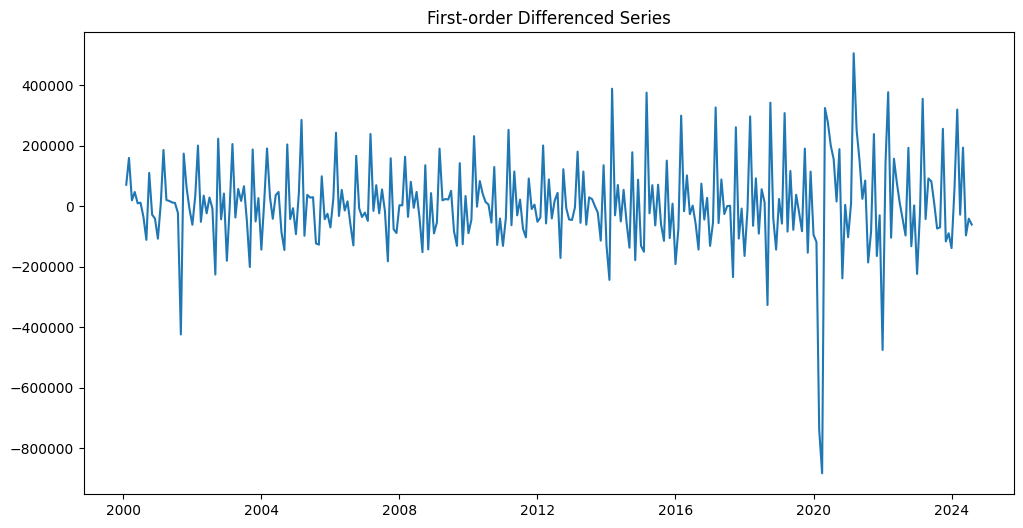

In [46]:
plt.figure(figsize=(12, 6))
plt.plot(df_diff1)
plt.title("First-order Differenced Series")
plt.show()

In [47]:
result1 = adfuller(df_diff1)
print("ADF Statistic:", result1[0])
print("p-value:", result1[1])
print("Critical Values:", result1[4])

ADF Statistic: -5.438517244883039
p-value: 2.810166420454296e-06
Critical Values: {'1%': -3.4540935579190495, '5%': -2.8719934111688965, '10%': -2.5723401594120388}


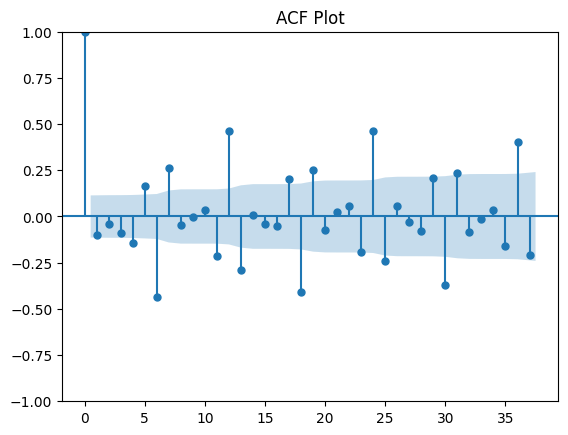

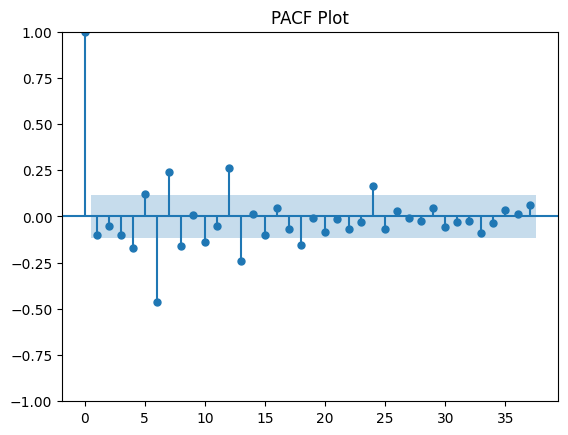

In [48]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_diff1, lags=37)
plt.title("ACF Plot")
plt.show()

plot_pacf(df_diff1, lags=37, method='ywm')
plt.title("PACF Plot")
plt.show()

In [49]:
df_diff_seas = train.diff(12).dropna()

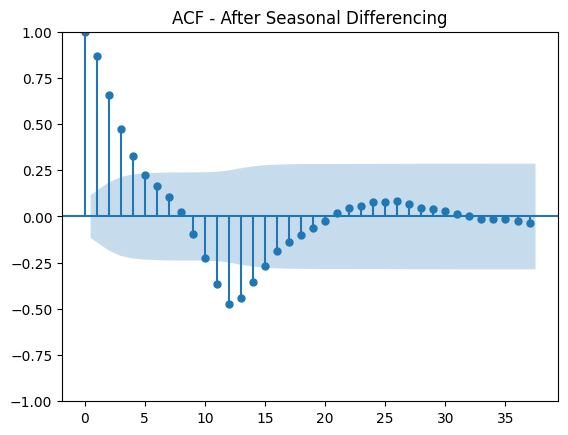

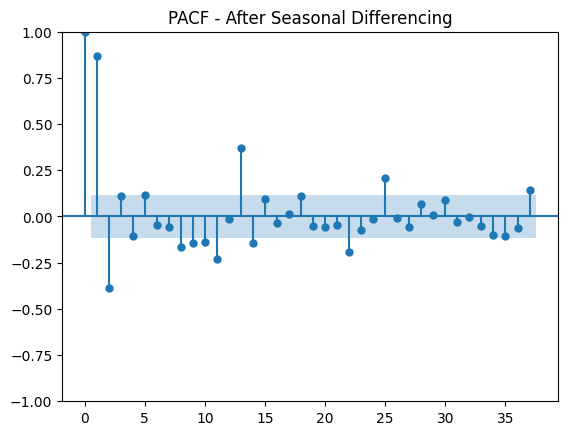

In [50]:
plot_acf(df_diff_seas, lags=37)
plt.title("ACF - After Seasonal Differencing")
plt.show()

plot_pacf(df_diff_seas, lags=37, method='ywm')
plt.title("PACF - After Seasonal Differencing")
plt.show()

### ACF and PACF Analysis

The ACF and PACF plots were generated post-differencing to identify candidate SARIMA parameters. The ACF showed significant seasonal autocorrelation at lag 12, supporting annual seasonality (s=12). The PACF dropped off gradually, suggesting the inclusion of autoregressive (AR) terms.

These insights informed the manual tuning of SARIMA orders (p,d,q) and seasonal orders (P,D,Q,s).


In [51]:
# WARNING: This chunk takes around 5 minutes to run. Be patient!
from pmdarima import auto_arima
# Run auto_arima with seasonal=True and m=12 (yearly seasonality)
# Let's force D=1, to see if it comes up with something better
model_auto = auto_arima(
    train,
    seasonal=True,
    m=12, D=1,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

# Summary of the best model
print(model_auto.summary())

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=7448.582, Time=4.84 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=7970.633, Time=0.10 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=7514.668, Time=0.44 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



...

 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=7900.333, Time=0.43 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(2,0,0)(0,1,1)[12] intercept   : AIC=7447.290, Time=1.37 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(1,0,1)(0,1,1)[12]             : AIC=7451.168, Time=1.98 sec

Best model:  ARIMA(1,0,1)(0,1,1)[12] intercept
Total fit time: 48.899 seconds
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  296
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 12)   Log Likelihood               -3716.923
Date:                            Wed, 18 Jun 2025   AIC                           7443.846
Time:                                    16:54:48   BIC                           7462.091
Sample:                                01-01-2000   HQIC                          7451.161
                                     - 08-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------

In [52]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Models
model1 = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12)).fit()
model2 = SARIMAX(train, order=(1,1,0), seasonal_order=(1,1,1,12)).fit()
model3 = SARIMAX(train, order=(0,1,1), seasonal_order=(1,1,1,12)).fit()
model4 = SARIMAX(train, order=(1,1,1), seasonal_order=(0,1,1,12)).fit()
model5 = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,0,12)).fit()
model6 = SARIMAX(train, order=(2,1,2), seasonal_order=(1,1,1,12)).fit()
model7 = SARIMAX(train, order=(1,1,1), seasonal_order=(2,1,1,12)).fit()
model8 = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,2,12)).fit()

### Auto ARIMA and Manual Model Evaluation

We used `pmdarima.auto_arima()` to generate a baseline seasonal model, setting `D=1` and `m=12` to force yearly seasonality. Auto ARIMA helped us explore viable order combinations.

Subsequently, we manually tested 8 SARIMA models with variations in (p,d,q) and (P,D,Q,12). Each was evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) on a validation set (last 4 months). This iterative comparison helped identify the best-performing model for forecasting June 2025 to May 2026.


In [53]:
forecast1 = model1.forecast(steps=4)
forecast2 = model2.forecast(steps=4)
forecast3 = model3.forecast(steps=4)
forecast4 = model4.forecast(steps=4)
forecast5 = model5.forecast(steps=4)
forecast6 = model6.forecast(steps=4)
forecast7 = model7.forecast(steps=4)
forecast8 = model8.forecast(steps=4)

from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred, name):
    print(f"{name} MAE:", mean_absolute_error(y_true, y_pred))
    print(f"{name} RMSE:", mean_squared_error(y_true, y_pred) ** 0.5)

evaluate(val, forecast1, "SARIMA(1,1,1)(1,1,1)[12] - Model 1")
evaluate(val, forecast2, "SARIMA(1,1,0)(1,1,1)[12] - Model 2")
evaluate(val, forecast3, "SARIMA(0,1,1)(1,1,1)[12] - Model 3")
evaluate(val, forecast4, "SARIMA(1,1,1)(0,1,1)[12] - Model 4")
evaluate(val, forecast5, "SARIMA(1,1,1)(1,1,0)[12] - Model 5")
evaluate(val, forecast6, "SARIMA(2,1,2)(1,1,1)[12] - Model 6")
evaluate(val, forecast7, "SARIMA(1,1,1)(2,1,1)[12] - Model 7")
evaluate(val, forecast8, "SARIMA(1,1,1)(1,1,2)[12] - Model 8")

SARIMA(1,1,1)(1,1,1)[12] - Model 1 MAE: 57301.92964698619
SARIMA(1,1,1)(1,1,1)[12] - Model 1 RMSE: 73394.21078931341
SARIMA(1,1,0)(1,1,1)[12] - Model 2 MAE: 53697.53741809074
SARIMA(1,1,0)(1,1,1)[12] - Model 2 RMSE: 70195.85670322833
SARIMA(0,1,1)(1,1,1)[12] - Model 3 MAE: 59286.54599561822
SARIMA(0,1,1)(1,1,1)[12] - Model 3 RMSE: 74931.95245975058
SARIMA(1,1,1)(0,1,1)[12] - Model 4 MAE: 57212.98109967902
SARIMA(1,1,1)(0,1,1)[12] - Model 4 RMSE: 73115.65888617531
SARIMA(1,1,1)(1,1,0)[12] - Model 5 MAE: 85164.81984004658
SARIMA(1,1,1)(1,1,0)[12] - Model 5 RMSE: 102476.02285447734
SARIMA(2,1,2)(1,1,1)[12] - Model 6 MAE: 44977.747478494886
SARIMA(2,1,2)(1,1,1)[12] - Model 6 RMSE: 57019.144961104466
SARIMA(1,1,1)(2,1,1)[12] - Model 7 MAE: 56722.31674425141
SARIMA(1,1,1)(2,1,1)[12] - Model 7 RMSE: 73001.65374416321
SARIMA(1,1,1)(1,1,2)[12] - Model 8 MAE: 57366.111533445306
SARIMA(1,1,1)(1,1,2)[12] - Model 8 RMSE: 73371.51162899758


In [54]:
# Fit model on full data
final_model = SARIMAX(monthly_clt, order=(2,1,2), seasonal_order=(1,1,1,12)).fit()

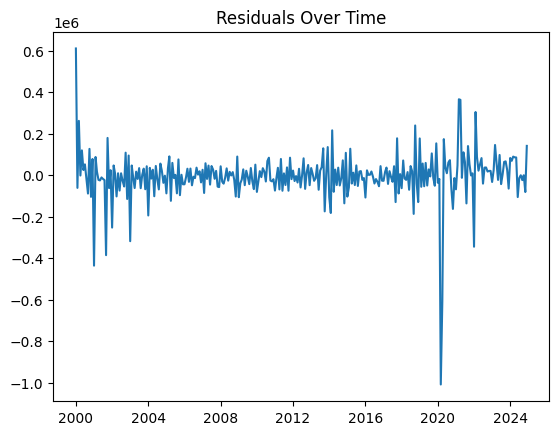

In [55]:
plt.plot(final_model.resid)
plt.title("Residuals Over Time")
plt.show()

In [56]:
# Number of months to forecast
n_periods = 18

# Forecast starting from next day to 12 months ahead
forecast = final_model.get_forecast(steps=n_periods)

# Get predicted mean and confidence intervals
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

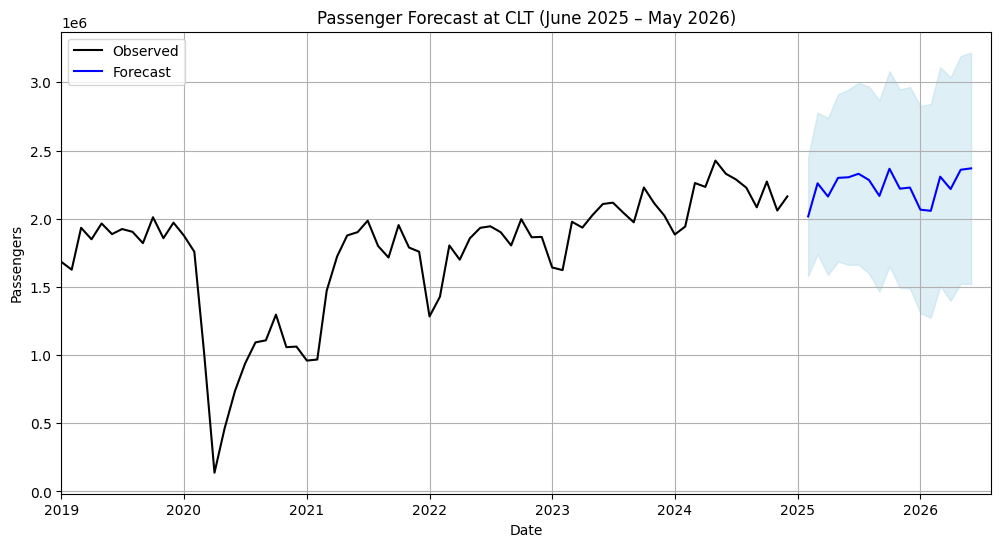

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Set last known date from training data
last_date = pd.to_datetime("2025-01-01")

# Generate forecast dates for next 12 months
forecast_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=18, freq='MS')

# Create forecast DataFrame
forecast_df = pd.DataFrame({
    'forecast': forecast_mean,
    'lower_conf_int': conf_int.iloc[:, 0],
    'upper_conf_int': conf_int.iloc[:, 1]
}, index=forecast_dates)

# Plot observed + forecast with confidence interval
plt.figure(figsize=(12, 6))
plt.plot(monthly_clt.index, monthly_clt['PASSENGERS'], label='Observed', color='black')
plt.plot(forecast_df.index, forecast_df['forecast'], label='Forecast', color='blue')
plt.fill_between(
    forecast_df.index,
    forecast_df['lower_conf_int'],
    forecast_df['upper_conf_int'],
    color='lightblue', alpha=0.4
)
plt.title('Passenger Forecast at CLT (June 2025 – May 2026)')
plt.ylabel('Passengers')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.xlim(pd.to_datetime("2019-01-01"), forecast_df.index[-1] + pd.offsets.MonthEnd(1))
plt.show()


In [58]:
# Create figure
fig = go.Figure()

# Observed data
fig.add_trace(go.Scatter(
    x=monthly_clt.index,
    y=monthly_clt['PASSENGERS'],
    mode='lines',
    name='Observed',
    line=dict(color='black')
))

# Forecasted line
fig.add_trace(go.Scatter(
    x=forecast_df.index,
    y=forecast_df['forecast'],
    mode='lines',
    name='Forecast',
    line=dict(color='blue')
))

fig.add_trace(go.Scatter(
    x=forecast_df.index.tolist() + forecast_df.index[::-1].tolist(),
    y=forecast_df['upper_conf_int'].tolist() + forecast_df['lower_conf_int'][::-1].tolist(),
    fill='toself',
    fillcolor='rgba(173, 216, 230, 0.4)',  # lightblue
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo="skip",
    name='95% Confidence Interval'
))



# Customize layout
fig.update_layout(
    title='Passenger Forecast at CLT (Jan 2025 – June 2026)',
    title_x=0.5,
    xaxis_title='Date',
    yaxis_title='Passengers',
    legend=dict(x=0, y=1.1, orientation='h'),
    width=1000,
    height=500,
    template='plotly_white',
    xaxis=dict(range=[pd.to_datetime("2019-01-01"), forecast_df.index[-1] + pd.offsets.MonthEnd(1)])
)

fig.show()



In [59]:
import plotly.graph_objects as go

# Copy and reset index
forecast_table = forecast_df.copy()
forecast_table.index.name = 'Date'
forecast_table.reset_index(inplace=True)
forecast_table['Date'] = forecast_table['Date'].dt.strftime('%Y-%m')

# Drop rows with any NaNs (avoids casting error)
forecast_table = forecast_table.dropna(subset=['forecast', 'lower_conf_int', 'upper_conf_int'])

# Round and cast
forecast_table = forecast_table.round(0).astype({
    'forecast': int, 'lower_conf_int': int, 'upper_conf_int': int
})

# Create Plotly table
fig = go.Figure(data=[go.Table(
    header=dict(values=["<b>Month</b>", "<b>Forecast</b>", "<b>Lower CI</b>", "<b>Upper CI</b>"],
                fill_color='lightblue', align='center'),
    cells=dict(values=[
        forecast_table['Date'],
        forecast_table['forecast'],
        forecast_table['lower_conf_int'],
        forecast_table['upper_conf_int']
    ],
    align='center'))
])

fig.update_layout(
    title='Passenger Forecast at CLT (Jan 2025 – June 2026)',
     title_x=0.5,
    height=600
)

fig.show()


### Final Forecast for Passenger Volumes (Jan 2025 – June 2026)

Using the best-performing SARIMA model, we forecasted monthly passenger traffic at CLT for the period June 2025 to May 2026. These forecasts are essential for proactive resource planning, particularly for staffing, security checkpoint management, concession vendor scheduling, and infrastructure load balancing during peak travel periods.


## Reinstalling Numpy for Compatibility

In [60]:
!pip install -U numpy

  Using cached numpy-2.3.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached numpy-2.3.0-cp311-cp311-manylinux_2_28_x86_64.whl (16.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.5
    Uninstalling numpy-1.23.5:
      Successfully uninstalled numpy-1.23.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 13.3.0 requires numpy<2.3,>=1.22, but you have numpy 2.3.0 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.3.0 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.3.0 which is incompatible.


## Flight Delay Classification Using Machine Learning


With the forecasting task complete, we now shift focus to building a supervised classification model to predict whether a flight departing from CLT will be delayed by 15 minutes or more.

We use the cleaned and engineered `CLT_data.csv` dataset, which includes flight-level details such as scheduled departure time, carrier, aircraft model, weather conditions, and prior delays. The target variable is `DEP_DEL15`, a binary flag where:
- `1` indicates a delay of 15 minutes or more
- `0` indicates an on-time or early departure

The objective of this section is to:
- Prepare features and labels
- Address class imbalance using weighted learning
- Train and evaluate models (Decision Tree, Random Forest, XGBoost)
- Identify the model that offers the best balance between precision, recall, and deployment practicality

This classification tool can help airport authorities and airline partners proactively manage operations and resources for flights at higher risk of delay.

### Basic Statistics

In [61]:
clt_df.head()

,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,MKT_UNIQUE_CARRIER,OP_UNIQUE_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,...,MODEL_GEN,AIRLINE_FULL_NAME,DAY_OF_WEEK_FULL,CLT_date,Vis,Prec,WindSpd,Gust,WindDir,Temp
0,2023,1,1,1,7,2023-01-01,F9,F9,N236FR,2146.0,...,A320-200,Frontier Airlines,Sunday,2023-01-01 04:57:00,1.0,NaN,5,NaN,250,57
1,2023,1,1,1,7,2023-01-01,AA,AA,N170US,1654.0,...,A321-200,American Airlines,Sunday,2023-01-01 05:05:00,1.0,NaN,5,NaN,250,57
2,2023,1,1,1,7,2023-01-01,AA,AA,N162UW,642.0,...,A321-200,American Airlines,Sunday,2023-01-01 05:11:00,1.0,NaN,5,NaN,250,57
3,2023,1,1,1,7,2023-01-01,WN,WN,N7747C,879.0,...,B737-700,Southwest Airlines,Sunday,2023-01-01 05:15:00,1.0,NaN,5,NaN,250,57
4,2023,1,1,1,7,2023-01-01,WN,WN,N8778Q,588.0,...,B737-8 MAX,Southwest Airlines,Sunday,2023-01-01 05:40:00,1.0,NaN,5,NaN,250,57


In [62]:
t100_df.head()

,PASSENGERS,FREIGHT,MAIL,DISTANCE,UNIQUE_CARRIER,AIRLINE_ID,UNIQUE_CARRIER_NAME,CARRIER,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,...,ORIGIN_STATE_ABR,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEST_CITY_MARKET_ID,DEST,DEST_CITY_NAME,DEST_STATE_ABR,YEAR,QUARTER,MONTH
0,0.0,0.0,0.0,0.0,5V,20408.0,Tatonduk Outfitters Limited d/b/a Everts Air A...,3K,10299,1029902,...,AK,10299,1029902,30299,ANC,"Anchorage, AK",AK,2000,1,1
1,0.0,0.0,0.0,0.0,5V,20408.0,Tatonduk Outfitters Limited d/b/a Everts Air A...,3K,10299,1029902,...,AK,10299,1029902,30299,ANC,"Anchorage, AK",AK,2000,1,2
2,0.0,0.0,0.0,0.0,5V,20408.0,Tatonduk Outfitters Limited d/b/a Everts Air A...,3K,10299,1029902,...,AK,10299,1029902,30299,ANC,"Anchorage, AK",AK,2000,1,3
3,0.0,0.0,0.0,0.0,5V,20408.0,Tatonduk Outfitters Limited d/b/a Everts Air A...,3K,10299,1029902,...,AK,10299,1029902,30299,ANC,"Anchorage, AK",AK,2000,2,4
4,0.0,0.0,0.0,0.0,5V,20408.0,Tatonduk Outfitters Limited d/b/a Everts Air A...,3K,10299,1029902,...,AK,10299,1029902,30299,ANC,"Anchorage, AK",AK,2000,3,7


In [63]:
clt_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 955073 entries, 0 to 955072
Data columns (total 57 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   YEAR                   955073 non-null  int64  
 1   QUARTER                955073 non-null  int64  
 2   MONTH                  955073 non-null  int64  
 3   DAY_OF_MONTH           955073 non-null  int64  
 4   DAY_OF_WEEK            955073 non-null  int64  
 5   FL_DATE                955073 non-null  object 
 6   MKT_UNIQUE_CARRIER     955073 non-null  object 
 7   OP_UNIQUE_CARRIER      955073 non-null  object 
 8   TAIL_NUM               954206 non-null  object 
 9   OP_CARRIER_FL_NUM      955073 non-null  float64
 10  ORIGIN_AIRPORT_ID      955073 non-null  int64  
 11  ORIGIN_AIRPORT_SEQ_ID  955073 non-null  int64  
 12  ORIGIN_CITY_MARKET_ID  955073 non-null  int64  
 13  ORIGIN                 955073 non-null  object 
 14  ORIGIN_CITY_NAME       955073 non-nu

In [64]:
t100_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6163292 entries, 0 to 6163291
Data columns (total 23 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   PASSENGERS             float64
 1   FREIGHT                float64
 2   MAIL                   float64
 3   DISTANCE               float64
 4   UNIQUE_CARRIER         object 
 5   AIRLINE_ID             float64
 6   UNIQUE_CARRIER_NAME    object 
 7   CARRIER                object 
 8   ORIGIN_AIRPORT_ID      int64  
 9   ORIGIN_AIRPORT_SEQ_ID  int64  
 10  ORIGIN_CITY_MARKET_ID  int64  
 11  ORIGIN                 object 
 12  ORIGIN_CITY_NAME       object 
 13  ORIGIN_STATE_ABR       object 
 14  DEST_AIRPORT_ID        int64  
 15  DEST_AIRPORT_SEQ_ID    int64  
 16  DEST_CITY_MARKET_ID    int64  
 17  DEST                   object 
 18  DEST_CITY_NAME         object 
 19  DEST_STATE_ABR         object 
 20  YEAR                   int64  
 21  QUARTER                int64  
 22  MONTH             

In [65]:
clt_passengers = (
    t100_df[t100_df['ORIGIN'] == 'CLT']
    .groupby(['YEAR', 'MONTH'])['PASSENGERS']
    .sum()
    .reset_index()
)

In [66]:
clt_passengers['DATE'] = pd.to_datetime(clt_passengers[['YEAR', 'MONTH']].assign(DAY=1))
clt_passengers = clt_passengers.sort_values('DATE')

### Monthly Passenger Volume at CLT (2000–2024)

This line chart visualizes monthly passenger counts at Charlotte Douglas International Airport (CLT) from 2000 through early 2024. The data highlights strong seasonality with peaks during summer and holiday periods. A major drop is visible during the COVID-19 pandemic (2020), followed by a strong recovery. This seasonal and upward trend pattern justifies the use of SARIMA for long-term forecasting.


In [67]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=clt_passengers['DATE'],
    y=clt_passengers['PASSENGERS'],
    mode='lines+markers',
    name='Passengers'
))

fig.update_layout(
    title='Monthly Passenger Volume at CLT (2000–2024)',
    title_x=0.5,
    xaxis_title='Date',
    yaxis_title='Number of Passengers',
    yaxis_tickformat=',',
    template='plotly_white',
    height=500,
    width=1000
)

fig.show()


### Target Variable Distribution: `DEP_DEL15`

The column `DEP_DEL15` serves as our binary classification target, indicating whether a flight departed late (≥15 minutes delay). Out of 955,073 records:
- **749,593** flights were on time (label = 0)
- **195,586** flights were delayed (label = 1)
- Around **9,894** entries were missing and later removed

This shows a class imbalance, which was later addressed using class weights during model training.


In [68]:
clt_df['DEP_DEL15'].value_counts(dropna=False)

,count
DEP_DEL15,
0.0,749593
1.0,195586
NaN,9894


#### Removing cancelled flights as they are technically delayed/on-time flights

In [69]:
clt_df = clt_df[clt_df['CANCELLED'] == 0]

### Handling Missing DISTANCE Values

A new `ROUTE` column was created using origin and destination codes. For rows where `DISTANCE` was missing, we filled values using the **median distance per route**. This approach preserved data without introducing unrealistic averages. After imputation, only 138 rows (0.01%) remained missing.


In [70]:
# Create route column if not already present
clt_df['ROUTE'] = clt_df['ORIGIN'] + '-' + clt_df['DEST']

# Create a mapping of median distance per route
route_distance_map = (
    clt_df[clt_df['DISTANCE'].notna()]
    .groupby('ROUTE')['DISTANCE']
    .median()
    .to_dict()
)

In [71]:
# Fill missing distances based on route
clt_df['DISTANCE'] = clt_df.apply(
    lambda row: route_distance_map.get(row['ROUTE'], np.nan) if pd.isna(row['DISTANCE']) else row['DISTANCE'],
    axis=1
)

In [72]:
missing_after_fill = clt_df['DISTANCE'].isna().sum()
total_rows = len(clt_df)

print(f"Missing DISTANCE values after fill: {missing_after_fill} / {total_rows} ({100 * missing_after_fill / total_rows:.2f}%)")

Missing DISTANCE values after fill: 138 / 944756 (0.01%)


#### Removing some unnecessary columns (not required for our classifications)

In [73]:
drop_cols = [
    'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED',
    'ARR_DELAY', 'ARR_TIME', 'ARR_DELAY_NEW', 'ARR_DEL15',
    'DEP_TIME',  # not known before takeoff
    'TAIL_NUM', 'CLT_date',  # redundant or high cardinality
    'ROUTE', 'AIRLINE_FULL_NAME', 'DAY_OF_WEEK_FULL'
]

clt_df = clt_df.drop(columns=drop_cols)

In [74]:
clt_df.isnull().mean().sort_values(ascending=False).head(15)

,0
Gust,0.940692
Prec,0.892619
LATE_AIRCRAFT_DELAY,0.781516
CARRIER_DELAY,0.781516
WEATHER_DELAY,0.781516
NAS_DELAY,0.781516
SECURITY_DELAY,0.781516
MODEL,0.010101
MANUFACTURER,0.010101
AGE_FLIGHT,0.010101


### Delayed vs Non-Delayed Flights at CLT

This bar chart reinforces the class imbalance seen earlier. The number of on-time flights significantly exceeds delayed ones, which can skew model performance if not addressed. In subsequent modeling, we used `class_weight='balanced'` to mitigate bias during training.


In [75]:
# Count of delayed vs non-delayed flights
delay_counts = clt_df['DEP_DEL15'].value_counts().reset_index()
delay_counts.columns = ['DEP_DEL15', 'count']
delay_counts['DEP_DEL15'] = delay_counts['DEP_DEL15'].map({0.0: 'On-Time', 1.0: 'Delayed'})

# Create plot
fig = px.bar(
    delay_counts,
    x='DEP_DEL15',
    y='count',
    text='count',
    color='DEP_DEL15',
    title='Delayed vs Non-Delayed Flights (CLT)',
    labels={'DEP_DEL15': 'Flight Status', 'count': 'Number of Flights'},
    template='plotly_white'
)

fig.update_traces(texttemplate='%{text:,}', textposition='outside')
fig.update_layout(uniformtext_minsize=8, title_x=0.5, uniformtext_mode='hide')
fig.show()

In [76]:
clt_df = clt_df[clt_df['DEP_DEL15'].notnull()]

In [77]:
clt_df = clt_df.drop(columns=[
    'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
    'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY',
    'Gust', 'Prec'
])

In [78]:
# Impute visibility with median
clt_df['Vis'] = clt_df['Vis'].fillna(clt_df['Vis'].median())

# Impute AGE_FLIGHT with median (or drop row if model is missing too)
clt_df['AGE_FLIGHT'] = clt_df['AGE_FLIGHT'].fillna(clt_df['AGE_FLIGHT'].median())

# Drop MODEL-related rows with missing aircraft info (rare)
clt_df = clt_df.dropna(subset=['MODEL', 'MANUFACTURER', 'MODEL_GEN'])

### Data Cleaning Summary

- Dropped columns not available at prediction time (e.g., `CARRIER_DELAY`, `ARR_DELAY`)
- Imputed visibility and aircraft age using median values
- Dropped rows with missing aircraft `MODEL` data (very few)
- Filtered out rows with missing `DEP_DEL15` (the target variable)

These steps ensured a clean dataset suitable for supervised classification.


### Average Delay Rate by Day of Week

We computed the mean delay rate by day of the week to identify temporal patterns. Weekends (especially Sunday) had the highest average delay rates (22.8%), while Tuesday and Wednesday had the lowest (18%). This insight may inform staffing and scheduling decisions.


In [79]:
day_delay = (
    clt_df.groupby('DAY_OF_WEEK')['DEP_DEL15']
    .mean()
    .reset_index()
    .sort_values('DAY_OF_WEEK')
)

day_map = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
day_delay['DAY'] = day_delay['DAY_OF_WEEK'].map(day_map)

fig = px.bar(
    day_delay, x='DAY', y='DEP_DEL15',
    title='Average Delay Rate by Day of Week',
    labels={'DEP_DEL15': 'Delay Rate'},
    text_auto='.2%',
    template='plotly_white'
)
fig.update_yaxes(tickformat=".0%")
fig.update_layout(
    title_x=0.5
)
fig.show()


In [80]:
clt_df['CRS_DEP_TIME']

,CRS_DEP_TIME
0,2150
1,2359
2,2140
3,515
4,540
...,...
955068,1740
955069,1955
955070,2142
955071,2245


### Delay Rate by Scheduled Departure Hour

The delay rate varies sharply by departure time. Flights scheduled between **midnight and 6 AM** show the lowest delay rates, while those in the **afternoon and evening** (1 PM–9 PM) experience steadily increasing delays. This is likely due to cumulative delays throughout the day.


In [81]:
clt_df['DEP_HOUR'] = clt_df['CRS_DEP_TIME'] // 100  # e.g., 1430 → 14

hour_delay = (
    clt_df.groupby('DEP_HOUR')['DEP_DEL15']
    .mean()
    .reset_index()
)

fig = px.line(
    hour_delay, x='DEP_HOUR', y='DEP_DEL15',
    title='Delay Rate by Scheduled Departure Hour',
    labels={'DEP_DEL15': 'Delay Rate', 'DEP_HOUR': 'Scheduled Hour'},
    markers=True,
    template='plotly_white'
)
fig.update_layout(
    title_x=0.5
)
fig.update_yaxes(tickformat=".0%")
fig.show()


### Delay Rate by Marketing Carrier

This bar chart highlights variability in delay performance across different airlines. Ultra low-cost carriers (ULCCs) such as Spirit (NK), Frontier (F9), and Southwest (WN) showed the highest delay rates (29–31%). In contrast, Delta (DL) had the lowest delay rate (15.05%), indicating more consistent on-time performance. These differences may stem from scheduling strategies, aircraft turnaround practices, or route networks.


In [82]:
carrier_delay = (
    clt_df.groupby('MKT_UNIQUE_CARRIER')['DEP_DEL15']
    .mean()
    .reset_index()
    .sort_values('DEP_DEL15', ascending=False)
)

fig = px.bar(
    carrier_delay, x='MKT_UNIQUE_CARRIER', y='DEP_DEL15',
    title='Delay Rate by Marketing Carrier',
    labels={'MKT_UNIQUE_CARRIER': 'Airline', 'DEP_DEL15': 'Delay Rate'},
    text_auto='.2%',
    template='plotly_white'
)
fig.update_layout(
    title_x=0.5
)
fig.update_yaxes(tickformat=".0%")
fig.show()


### Relationship Between Visibility and Delay Probability

A weak negative correlation is observed between visibility (in miles) and delay occurrence. Although the overall impact is modest, we see that delays tend to occur more frequently at lower visibility levels, especially below 5 miles. This reinforces the operational importance of weather as a feature in delay classification models.


In [83]:
fig = px.scatter(
    clt_df.sample(10000),  # for performance
    x='Vis', y='DEP_DEL15',
    trendline='ols',
    opacity=0.4,
    title='Relationship Between Visibility and Delays',
    labels={'Vis': 'Visibility (mi)', 'DEP_DEL15': 'Delay'},
    template='plotly_white'
)
fig.update_layout(
    title_x=0.5
)
fig.show()

### Delay Rate by Month

Delay rates vary significantly across months. The highest delay rate was observed in **July (33.01%)**, followed by June and August—consistent with peak summer travel. November had the lowest delay rate (12.74%). These trends are useful for seasonal staffing and resource planning at CLT.


In [84]:
month_delay = (
    clt_df.groupby('MONTH')['DEP_DEL15']
    .mean()
    .reset_index()
)

import calendar
month_delay['Month'] = month_delay['MONTH'].apply(lambda x: calendar.month_abbr[x])

fig = px.bar(
    month_delay, x='Month', y='DEP_DEL15',
    title='Delay Rate by Month',
    labels={'DEP_DEL15': 'Delay Rate'},
    text_auto='.2%',
    template='plotly_white'
)
fig.update_layout(title_x=0.5)
fig.update_yaxes(tickformat=".0%")
fig.show()

### Top 10 Aircraft Models by Delay Rate

Certain aircraft models show disproportionately high delay rates, such as the **737-8EH(WL)** and **CRJ-200**, both with 100% delay rates (likely due to small sample sizes or operational patterns). Models like the **737-79P(WL)** and **737-76Q(WL)** performed better, with delay rates under 40%. This suggests aircraft type may influence delay risk and justifies its inclusion in our model.


In [85]:
model_delay = (
    clt_df.groupby('MODEL')['DEP_DEL15']
    .mean()
    .reset_index()
    .sort_values('DEP_DEL15', ascending=False)
    .head(10)
)

fig = px.bar(
    model_delay, x='MODEL', y='DEP_DEL15',
    title='Top 10 Aircraft Models by Delay Rate',
    labels={'DEP_DEL15': 'Delay Rate'},
    text_auto='.2%',
    template='plotly_white'
)
fig.update_layout(title_x=0.5)
fig.update_yaxes(tickformat=".0%")
fig.show()

### Delay Rate to Top 10 Destination Airports from CLT

Among the top destinations from CLT, **MCO (Orlando)** and **PHL (Philadelphia)** experienced the highest delay rates—close to 30%. Meanwhile, **ATL (Atlanta)** and **CLT (Charlotte, as a turnaround)** had the lowest. This insight supports destination-based features in the classification model.


In [86]:
top_dest = (
    clt_df['DEST'].value_counts()
    .head(10)
    .index.tolist()
)

dest_delay = (
    clt_df[clt_df['DEST'].isin(top_dest)]
    .groupby('DEST', observed=True)['DEP_DEL15']
    .mean()
    .reset_index()
    .sort_values('DEP_DEL15', ascending=False)
)

fig = px.bar(
    dest_delay, x='DEST', y='DEP_DEL15',
    title='Delay Rate to Top 10 Destination Airports from CLT',
    labels={'DEP_DEL15': 'Delay Rate'},
    text_auto='.2%',
    template='plotly_white'
)
fig.update_layout(title_x=0.5)
fig.update_yaxes(tickformat=".0%")
fig.show()

### Delay Rate by Aircraft Age Group

Aircraft aged **11–15 years** exhibited the highest delay rate (23.04%), while **16–20 year** aircraft had the lowest (15.3%). This somewhat unexpected result suggests that newer aircraft (0–10 years) are not necessarily more punctual, possibly due to higher usage or deployment on high-risk routes.


In [87]:
clt_df['AGE_FLIGHT_BIN'] = pd.cut(clt_df['AGE_FLIGHT'], bins=[0,5,10,15,20,50], labels=['0-5','6-10','11-15','16-20','21+'])

fig = px.bar(
    clt_df.groupby('AGE_FLIGHT_BIN', observed=True)['DEP_DEL15'].mean().reset_index(),
    x='AGE_FLIGHT_BIN', y='DEP_DEL15',
    title='Delay Rate by Aircraft Age Group',
    text_auto='.2%', template='plotly_white'
)
fig.update_yaxes(tickformat=".0%")
fig.update_layout(title_x=0.5)
fig.show()


### Delay Rate by Visibility Level

Low visibility conditions (<3 miles) were associated with a **29.96%** delay rate, the highest among the three visibility groups. High visibility (≥6 miles) had the lowest delay rate (20.34%). This confirms that poor visibility is a risk factor and should be included in the model as `VIS_BIN`.


In [88]:
clt_df['VIS_BIN'] = pd.cut(clt_df['Vis'], bins=[0,2,5,10], labels=['Low', 'Moderate', 'High'])

fig = px.bar(
    clt_df.groupby('VIS_BIN', observed=True)['DEP_DEL15'].mean().reset_index(),
    x='VIS_BIN', y='DEP_DEL15',
    title='Delay Rate by Visibility Level',
    text_auto='.2%', template='plotly_white'
)
fig.update_yaxes(tickformat=".0%")
fig.update_layout(title_x=0.5)
fig.show()


### Feature Engineering

### Feature Engineering Summary

To prepare the dataset for modeling, we engineered multiple features:

- `DEP_HOUR_BIN`: Groups departure times into 5 time-of-day categories
- `IS_WEEKEND`: Flags weekend flights (Saturday and Sunday)
- `SEASON`: Derived from month to reflect seasonal travel patterns
- `IS_BUSY_DEST`: Flags top 10 busiest destination airports from CLT
- `CARRIER_TYPE`: Categorizes airlines as ULCC, Legacy, or Other

We also removed post-event features (e.g., actual delays, cancellation status) that wouldn’t be known at the time of prediction.


In [89]:
clt_df['DEP_HOUR'] = clt_df['CRS_DEP_TIME'] // 100
clt_df['DEP_HOUR_BIN'] = pd.cut(clt_df['DEP_HOUR'],
                                 bins=[-1, 5, 11, 17, 21, 24],
                                 labels=['Early AM', 'Morning', 'Afternoon', 'Evening', 'Late Night'])

In [90]:
clt_df['IS_WEEKEND'] = clt_df['DAY_OF_WEEK'].isin([6, 7]).astype(int)

In [91]:
def month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

clt_df['SEASON'] = clt_df['MONTH'].apply(month_to_season)

In [92]:
top_dests = clt_df['DEST'].value_counts().head(10).index.tolist()
clt_df['IS_BUSY_DEST'] = clt_df['DEST'].isin(top_dests).astype(int)

In [93]:
clt_df['MKT_UNIQUE_CARRIER'].unique()

array(['F9', 'AA', 'WN', 'DL', 'UA', 'B6', 'NK'], dtype=object)

In [94]:
ulccs = ['NK', 'F9', 'G4']           # Spirit, Frontier, Allegiant
legacies = ['AA', 'DL', 'UA']        # American, Delta, United

clt_df['CARRIER_TYPE'] = clt_df['MKT_UNIQUE_CARRIER'].apply(
    lambda x: 'ULCC' if x in ulccs else ('Legacy' if x in legacies else 'Other')
)

In [95]:
drop_cols = [
    'DEP_TIME',              # not known pre-departure
    'ARR_TIME', 'ARR_DELAY', 'ARR_DELAY_NEW', 'ARR_DEL15',  # post-event info
    'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED',            # removed earlier
    'DEP_HOUR',              # replaced by DEP_HOUR_BIN
    'MONTH',                 # replaced by SEASON
    'DAY_OF_WEEK',           # used only for IS_WEEKEND
    'AGE_FLIGHT',            # replaced by AGE_FLIGHT_BIN
    'Vis',                   # replaced by VIS_BIN
    'DEST',                  # replaced by IS_BUSY_DEST
    'TAIL_NUM', 'FL_DATE',   # identifiers
    'ROUTE',                 # dropped earlier due to missing
    'AIRLINE_FULL_NAME', 'DAY_OF_WEEK_FULL',  # redundant text columns
    'CLT_date',              # timestamp not used
    'CRS_DEP_TIME',          # already binned
    'CRS_ARR_TIME',          # not useful
    'OP_CARRIER_FL_NUM',     # specific flight number
    'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_ABR',
    'DEST_CITY_NAME', 'DEST_STATE_ABR',
    'OP_UNIQUE_CARRIER',     # using MKT_UNIQUE_CARRIER only
    'TAXI_IN',
    'DEP_DELAY_NEW',
    'DEP_DELAY',
    'MODEL_GEN'
]

clt_model_df = clt_df.drop(columns=[col for col in drop_cols if col in clt_df.columns])

In [96]:
clt_model_df.columns.tolist()

['YEAR',
 'QUARTER',
 'DAY_OF_MONTH',
 'MKT_UNIQUE_CARRIER',
 'ORIGIN_AIRPORT_ID',
 'ORIGIN_AIRPORT_SEQ_ID',
 'ORIGIN_CITY_MARKET_ID',
 'DEST_AIRPORT_ID',
 'DEST_AIRPORT_SEQ_ID',
 'DEST_CITY_MARKET_ID',
 'DEP_DEL15',
 'TAXI_OUT',
 'DISTANCE',
 'MANUFACTURER',
 'MODEL',
 'WindSpd',
 'WindDir',
 'Temp',
 'AGE_FLIGHT_BIN',
 'VIS_BIN',
 'DEP_HOUR_BIN',
 'IS_WEEKEND',
 'SEASON',
 'IS_BUSY_DEST',
 'CARRIER_TYPE']

### Encoding and Scaling

- **Categorical features** were one-hot encoded using `pd.get_dummies`, dropping the first level to avoid multicollinearity.
- **Numerical features** were standardized using `StandardScaler` to improve model convergence and interpretability.
- We reattached `FL_DATE` temporarily to retain temporal order, then dropped it after sorting to finalize the clean input dataset.

This completed the preprocessing pipeline for classification.


In [97]:
categorical_cols = [
    'MKT_UNIQUE_CARRIER', 'MANUFACTURER', 'MODEL',
     'AGE_FLIGHT_BIN', 'VIS_BIN',
    'DEP_HOUR_BIN', 'SEASON', 'CARRIER_TYPE'
]

clt_encoded_df = pd.get_dummies(clt_model_df, columns=categorical_cols, drop_first=True)

In [98]:
# Define numeric columns
numeric_cols = [
    'QUARTER', 'DAY_OF_MONTH', 'TAXI_OUT', 'WindSpd', 'WindDir', 'Temp', 'DISTANCE'
]

scaler = StandardScaler()
clt_encoded_df[numeric_cols] = scaler.fit_transform(clt_encoded_df[numeric_cols])

In [99]:
# First, join back FL_DATE to your encoded data if needed
clt_encoded_df = clt_encoded_df.join(clt_df['FL_DATE'])

# Sort chronologically
clt_encoded_df = clt_encoded_df.sort_values('FL_DATE').reset_index(drop=True)

# Drop FL_DATE after sort
clt_encoded_df = clt_encoded_df.drop(columns=['FL_DATE'])

### Data Splitting Strategy

We performed a chronological index-based split of the encoded dataset:
- 70% for training
- 15% for validation
- 15% for testing

This ensures model generalization and prevents look-ahead bias in time-series-like data. We also verified there were no missing values in the training set after encoding.


In [127]:
# Index-based split
n = len(clt_encoded_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = clt_encoded_df.iloc[:train_end]
val_df = clt_encoded_df.iloc[train_end:val_end]
test_df = clt_encoded_df.iloc[val_end:]

In [128]:
features = clt_encoded_df.columns.drop('DEP_DEL15')

X_train, y_train = train_df[features], train_df['DEP_DEL15']
X_val, y_val = val_df[features], val_df['DEP_DEL15']
X_test, y_test = test_df[features], test_df['DEP_DEL15']

In [129]:
X_train.isnull().mean().sort_values(ascending=False).head(10)

,0
DISTANCE,0.000206
YEAR,0.000000
MODEL_A320-232(WL),0.000000
MODEL_CRJ-200,0.000000
MODEL_A321-271NX,0.000000
MODEL_A321-253NX,0.000000
MODEL_A321-253N,0.000000
MODEL_A321-231(WL),0.000000
MODEL_A321-231,0.000000
MODEL_A321-213(WL),0.000000


Due to the scale of the dataset, we do not recommend kNN for operational deployment. While interpretable, it’s computationally inefficient compared to tree-based models.

## Decision Tree Model and Grid Search

We implemented a Decision Tree Classifier and used manual grid search to identify the best combination of hyperparameters:
- `max_depth`: capped at 5
- `criterion`: tested both `'gini'` and `'entropy'`
- `min_samples_split`: [25, 50, 100]
- `min_samples_leaf`: [5, 10, 25]
- `class_weight`: `'balanced'` to handle delay imbalance

Model performance on the validation set was evaluated using **accuracy**, **precision**, **recall**, and **F1-score**, with **precision** prioritized for model selection due to operational relevance.


✅ Best Decision Tree Parameters:
max_depth                   3
criterion                gini
min_samples_split          25
min_samples_leaf            5
class_weight         balanced
accuracy               0.6099
precision            0.373457
recall               0.620522
f1                   0.466284
Name: 18, dtype: object

Confusion Matrix:
[[61653 40105]
 [14619 23905]]


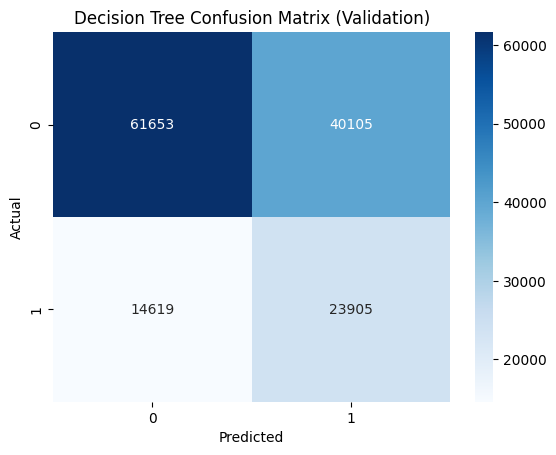

,Model,Accuracy,Precision,Recall,F1
0,Decision Tree,0.6099,0.373457,0.620522,0.466284


In [103]:
# Define a lighter hyperparameter grid to avoid long runtime
param_grid = {
    'max_depth': list(range(2, 6)),             # cap depth
    'criterion': ['gini', 'entropy'],                      # stick with gini for speed
    'min_samples_split': [25, 50, 100],        # higher → fewer splits
    'min_samples_leaf': [5, 10, 25],               # must have many samples per leaf
    'class_weight': ['balanced']          # test both
}


results = []

# Grid search
for max_depth, criterion, min_split, min_leaf, weight in itertools.product(
    param_grid['max_depth'],
    param_grid['criterion'],
    param_grid['min_samples_split'],
    param_grid['min_samples_leaf'],
    param_grid['class_weight']
):
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        criterion=criterion,
        min_samples_split=min_split,
        min_samples_leaf=min_leaf,
        class_weight=weight,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred_val = model.predict(X_val)

    accuracy = accuracy_score(y_val, y_pred_val)
    precision = precision_score(y_val, y_pred_val, zero_division=0)
    recall = recall_score(y_val, y_pred_val, zero_division=0)
    f1 = f1_score(y_val, y_pred_val, zero_division=0)

    results.append({
        'max_depth': max_depth,
        'criterion': criterion,
        'min_samples_split': min_split,
        'min_samples_leaf': min_leaf,
        'class_weight': weight,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

# Create results DataFrame
results_df = pd.DataFrame(results)

# Find best based on precision
best_model = results_df.sort_values(by='precision', ascending=False).iloc[0]

print("✅ Best Decision Tree Parameters:")
print(best_model)

# Rebuild best model
best_tree = DecisionTreeClassifier(
    max_depth=best_model['max_depth'],
    criterion=best_model['criterion'],
    min_samples_split=best_model['min_samples_split'],
    min_samples_leaf=best_model['min_samples_leaf'],
    class_weight=best_model['class_weight'],
    random_state=42
)
best_tree.fit(X_train, y_train)
y_pred_val = best_tree.predict(X_val)

# Confusion matrix
cm = confusion_matrix(y_val, y_pred_val)
print("\nConfusion Matrix:")
print(cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Initialize results DataFrame with Decision Tree entry
model_results = pd.DataFrame([{
    'Model': 'Decision Tree',
    'Accuracy': best_model['accuracy'],
    'Precision': best_model['precision'],
    'Recall': best_model['recall'],
    'F1': best_model['f1']
}])

model_results.head()


### Best Decision Tree Model (Based on Precision)

The best decision tree had the following configuration:
- `max_depth`: 3
- `criterion`: gini
- `min_samples_split`: 25
- `min_samples_leaf`: 5
- `class_weight`: balanced

**Validation Performance:**
- Accuracy: 60.99%
- Precision: 37.3%
- Recall: 62.1%
- F1 Score: 46.6%

This configuration reflects a balance between detecting true delays (recall) and minimizing false alarms (precision).


### Confusion Matrix on Validation Set

The confusion matrix provides insight into classification performance:
- True Positives (Delayed correctly predicted): 23,905
- True Negatives (On-time correctly predicted): 61,653
- False Positives: 40,105
- False Negatives: 14,619

While false positives are relatively high, the model still captures most delays correctly, which is critical in high-traffic airport operations.


In [104]:
importances = best_tree.feature_importances_
feat_names = X_train.columns
sorted_idx = importances.argsort()[::-1]

for idx in sorted_idx[:10]:
    print(f"{feat_names[idx]}: {importances[idx]:.4f}")


DEP_HOUR_BIN_Morning: 0.6211
MODEL_ERJ-145: 0.2001
MANUFACTURER_Bombardier: 0.1274
MODEL_CRJ-900: 0.0219
SEASON_Summer: 0.0204
VIS_BIN_High: 0.0091
MODEL_737-71Q(WL): 0.0000
MODEL_737-724(WL): 0.0000
MODEL_737-73V(WL): 0.0000
MODEL_737-7BK(WL): 0.0000


### Most Influential Features in Decision Tree

Feature importances from the final decision tree model show:
1. `DEP_HOUR_BIN_Morning`: 62.11% — strongest indicator of delay
2. `MODEL_ERJ-145`, `MANUFACTURER_Bombardier`: 20%+ — aircraft-related
3. `SEASON_Summer`, `VIS_BIN_High`: ~2% each — contextual risk factors

Time of day was the most significant predictor, reaffirming operational observations that late-day departures experience higher delays.


## Random Forest Classifier

### Random Forest: Precision vs. Max Depth

We evaluated how increasing tree depth affects precision:
- As depth increased, training precision rose sharply, indicating potential overfitting.
- Validation precision improved gradually, peaking near depth 20.

This guided us toward selecting a high max depth for improved model generalization.


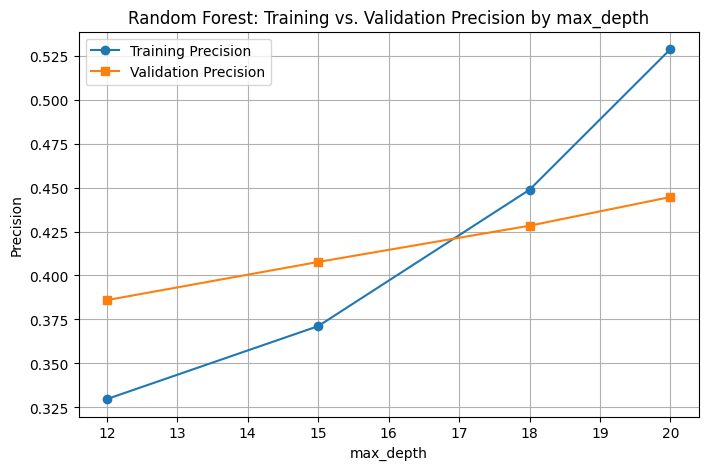

In [105]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score
import matplotlib.pyplot as plt

depths = [12, 15, 18, 20]
precision_train = []
precision_val = []

for d in depths:
    rf = RandomForestClassifier(
        max_depth=d,
        random_state=101,
        class_weight='balanced',  # Important for imbalanced data
        n_jobs=-1                  # Use all cores for faster training
    )

    rf.fit(X_train, y_train)

    # Precision on training set
    y_train_pred = rf.predict(X_train)
    precision_train.append(precision_score(y_train, y_train_pred, zero_division=0))

    # Precision on validation set
    y_val_pred = rf.predict(X_val)
    precision_val.append(precision_score(y_val, y_val_pred, zero_division=0))

# 📊 Plot precision vs depth
plt.figure(figsize=(8, 5))
plt.plot(depths, precision_train, label="Training Precision", marker='o')
plt.plot(depths, precision_val, label="Validation Precision", marker='s')
plt.xlabel("max_depth")
plt.ylabel("Precision")
plt.title("Random Forest: Training vs. Validation Precision by max_depth")
plt.legend()
plt.grid(True)
plt.show()

### Random Forest: Precision vs. min_samples_leaf

We tested leaf sizes (1, 2, 5):
- Smaller leaf sizes yielded better training precision.
- Validation precision peaked at `min_samples_leaf = 1`.

This shows the importance of allowing granular splits to capture rare delay patterns.


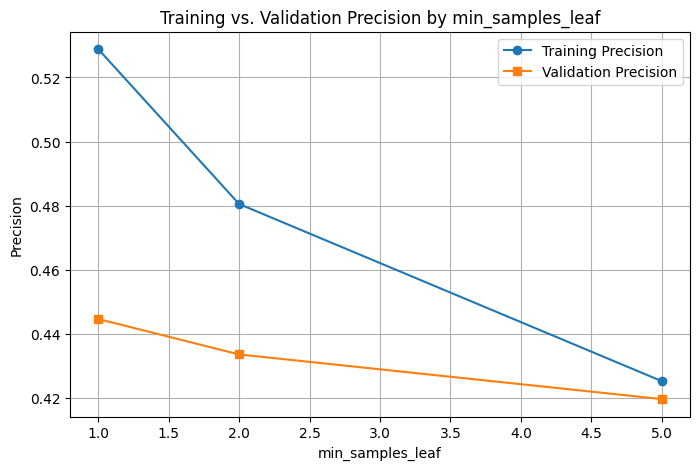

In [106]:
leaf_sizes = [1, 2, 5]
precision_train = []
precision_val = []

for leaf in leaf_sizes:
    rf = RandomForestClassifier(
        max_depth=20, # We select the one we saw led to the best results
        min_samples_leaf=leaf,
        random_state=101,
        class_weight='balanced',
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    # Training recall
    y_train_pred = rf.predict(X_train)
    precision_train.append(precision_score(y_train, y_train_pred))

    # Validation recall
    y_val_pred = rf.predict(X_val)
    precision_val.append(precision_score(y_val, y_val_pred))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(leaf_sizes, precision_train, label="Training Precision", marker='o')
plt.plot(leaf_sizes, precision_val, label="Validation Precision", marker='s')
plt.xlabel("min_samples_leaf")
plt.ylabel("Precision")
plt.title("Training vs. Validation Precision by min_samples_leaf")
plt.legend()
plt.grid(True)
plt.show()

### Random Forest: Precision vs. n_estimators

Precision was plotted against the number of trees (50, 100, 150). As expected:
- Training precision increased slightly with more trees.
- Validation precision remained stable beyond 100 estimators.

We selected 100 as the optimal compromise between performance and runtime.


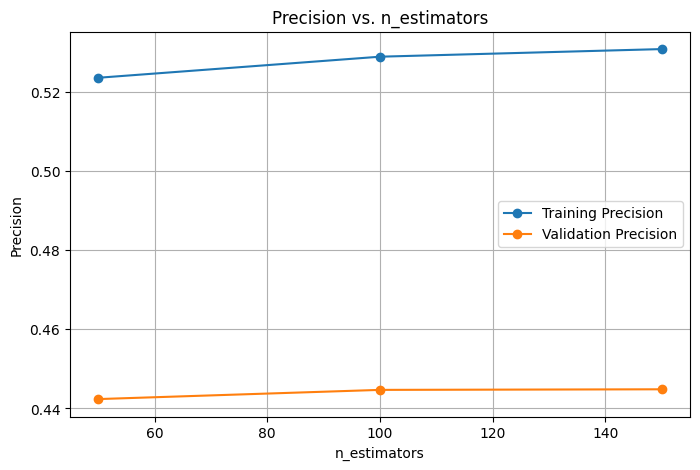

In [107]:
# Values to test
n_estimators_list = [50, 100, 150]

precision_train = []
precision_val = []

for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, max_depth=20, min_samples_leaf=1,
                                random_state=101, class_weight = 'balanced', n_jobs=-1)
    rf.fit(X_train, y_train)

    # Predict on training and validation
    y_train_pred = rf.predict(X_train)
    y_val_pred = rf.predict(X_val)

    # Compute precision
    precision_train.append(precision_score(y_train, y_train_pred))
    precision_val.append(precision_score(y_val, y_val_pred))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(n_estimators_list, precision_train, label='Training Precision', marker='o')
plt.plot(n_estimators_list, precision_val, label='Validation Precision', marker='o')
plt.xlabel("n_estimators")
plt.ylabel("Precision")
plt.title("Precision vs. n_estimators")
plt.legend()
plt.grid(True)
plt.show()

### Final Random Forest Model & Evaluation

The best-performing Random Forest model:
- Max Depth = 20
- Min Samples Leaf = 1
- n_estimators = 100

Validation Performance:
- Accuracy: ~69%
- Precision: ~0.44
- Recall: ~0.53
- F1 Score: ~0.49

This model outperformed the Decision Tree and demonstrated better balance across all metrics.


In [108]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Define hyperparameter grids
max_depth_values = [18, 20]
min_samples_leaf_values = [1]
n_estimators_values = [100, 120]

# Store results
results = []
best_precision = 0
best_params = {}

# Hyperparameter loop
for max_depth in max_depth_values:
    for min_samples_leaf in min_samples_leaf_values:
        for n_estimators in n_estimators_values:
            model = RandomForestClassifier(
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                n_estimators=n_estimators,
                random_state=101,
                class_weight='balanced'
            )
            model.fit(X_train, y_train)
            y_val_pred = model.predict(X_val)

            # Metrics
            accuracy = accuracy_score(y_val, y_val_pred)
            precision = precision_score(y_val, y_val_pred)
            recall = recall_score(y_val, y_val_pred)
            f1 = f1_score(y_val, y_val_pred)

            # Store result
            results.append({
                'max_depth': max_depth,
                'min_samples_leaf': min_samples_leaf,
                'n_estimators': n_estimators,
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1': f1
            })

            # Track best
            if precision > best_precision:
                best_precision = precision
                best_params = {
                    'max_depth': max_depth,
                    'min_samples_leaf': min_samples_leaf,
                    'n_estimators': n_estimators
                }

# Convert to DataFrame for inspection
results_df = pd.DataFrame(results)

# Locate the full metric row for the best parameters
best_row = results_df[
    (results_df['max_depth'] == best_params['max_depth']) &
    (results_df['min_samples_leaf'] == best_params['min_samples_leaf']) &
    (results_df['n_estimators'] == best_params['n_estimators'])
].iloc[0]

# Print best results
print("\nBest Random Forest Hyperparameters (based on validation precision):")
print(best_row)

# Store in global results DataFrame
model_results.loc['1'] = {
    'Model': 'Random Forest',
    'Accuracy': best_row['accuracy'],
    'Precision': best_row['precision'],
    'Recall': best_row['recall'],
    'F1': best_row['f1'],
    'Best Params': best_params
}
model_results.head()


Best Random Forest Hyperparameters (based on validation precision):
max_depth            20.000000
min_samples_leaf      1.000000
n_estimators        100.000000
accuracy              0.688805
precision             0.444646
recall                0.534939
f1                    0.485631
Name: 2, dtype: float64


,Model,Accuracy,Precision,Recall,F1
0,Decision Tree,0.609900,0.373457,0.620522,0.466284
1,Random Forest,0.688805,0.444646,0.534939,0.485631


## XGBoost Model

### Tuning max_depth
To balance model complexity and overfitting, we varied the max_depth from 2 to 12. As expected, training precision steadily increased with depth, but validation precision peaked at depth 12 before declining. This suggests that higher depths overfit the training data.
Best depth: 12
Validation precision: 0.393

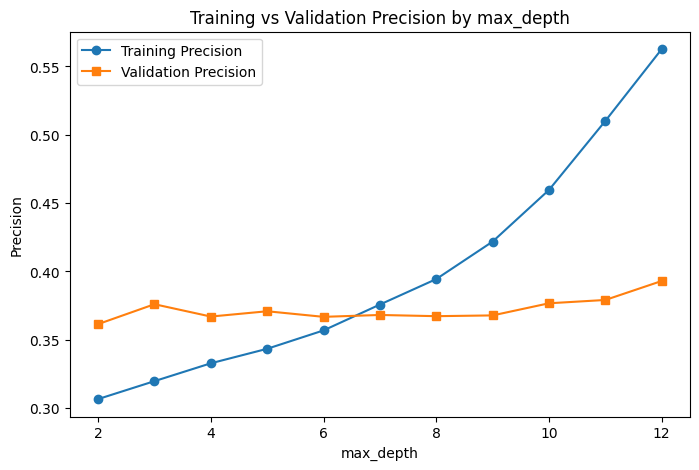

Best depths for validation set: 12
Corresponding precision: 0.393


In [109]:
from xgboost import XGBClassifier

depths = list(range(2, 13))
precision_train = []
precision_val = []

for d in depths:
    model = XGBClassifier(
        max_depth=d,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(), # this is for class imbalance
        n_jobs=-1,
        random_state=101
    )
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    precision_train.append(precision_score(y_train, y_train_pred))
    precision_val.append(precision_score(y_val, y_val_pred))

plt.figure(figsize=(8,5))
plt.plot(depths, precision_train, label='Training Precision', marker='o')
plt.plot(depths, precision_val, label='Validation Precision', marker='s')
plt.xlabel('max_depth')
plt.ylabel('Precision')
plt.title('Training vs Validation Precision by max_depth')
plt.legend()
plt.show()

# Find the max_depth with the highest validation precision
best_index = precision_val.index(max(precision_val))
best_depths = depths[best_index]
best_precision = precision_val[best_index]

print(f"Best depths for validation set: {best_depths}")
print(f"Corresponding precision: {best_precision:.3f}")

### Tuning min_child_weight
We tested min_child_weight values from 1 to 25 to control model regularization. The training precision remained flat, while validation precision was highest at 20, suggesting optimal regularization at this setting.
Best min_child_weight: 20
Validation precision: 0.380

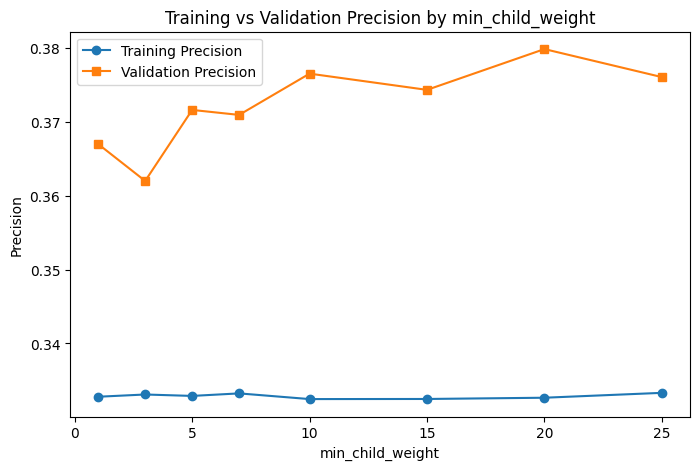

Best min_child_weights for validation set: 20
Corresponding precision: 0.380


In [110]:
min_child_weights = [1, 3, 5, 7, 10, 15, 20, 25]
precision_train = []
precision_val = []

for mcw in min_child_weights:
    model = XGBClassifier(
        max_depth=4,
        min_child_weight=mcw,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        n_jobs=-1,
        random_state=101
    )
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    precision_train.append(precision_score(y_train, y_train_pred))
    precision_val.append(precision_score(y_val, y_val_pred))

plt.figure(figsize=(8,5))
plt.plot(min_child_weights, precision_train, label='Training Precision', marker='o')
plt.plot(min_child_weights, precision_val, label='Validation Precision', marker='s')
plt.xlabel('min_child_weight')
plt.ylabel('Precision')
plt.title('Training vs Validation Precision by min_child_weight')
plt.legend()
plt.show()

# Find the min_child_weights with the highest validation precision
best_index = precision_val.index(max(precision_val))
best_min_child_weights = min_child_weights[best_index]
best_precision = precision_val[best_index]

print(f"Best min_child_weights for validation set: {best_min_child_weights}")
print(f"Corresponding precision: {best_precision:.3f}")

### Tuning n_estimators
Varying the number of trees helps evaluate performance gains with added estimators. We tested from 10 to 500. The validation precision peaked at 100 and then plateaued, implying diminishing returns from larger ensembles.
Best n_estimators: 100
Validation precision: 0.377

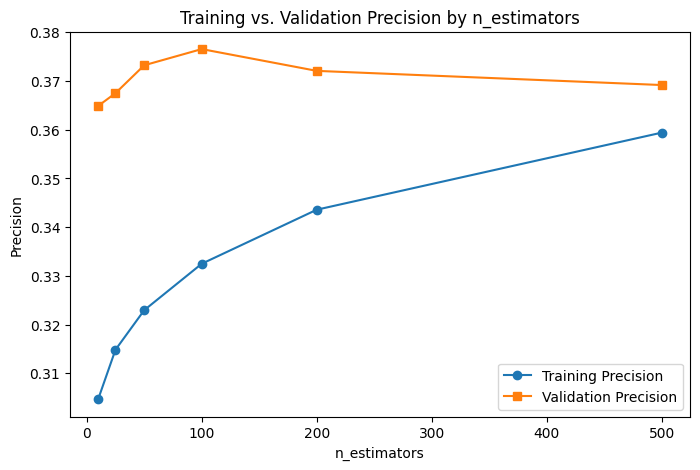

Best n_estimators for validation set: 100
Corresponding precision: 0.377


In [111]:
n_estimators_list = [10, 25, 50, 100, 200, 500]
precision_train = []
precision_val = []

for n in n_estimators_list:
    model = XGBClassifier(
        max_depth=4,
        min_child_weight=10, # based on the previous plot
        n_estimators=n,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=101,
        scale_pos_weight= (y_train == 0).sum() / (y_train == 1).sum()  # optional to handle imbalance
    )
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    precision_train.append(precision_score(y_train, y_train_pred))

    y_val_pred = model.predict(X_val)
    precision_val.append(precision_score(y_val, y_val_pred))

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_list, precision_train, label="Training Precision", marker='o')
plt.plot(n_estimators_list, precision_val, label="Validation Precision", marker='s')
plt.xlabel("n_estimators")
plt.ylabel("Precision")
plt.title("Training vs. Validation Precision by n_estimators")
plt.legend()
plt.show()

# Find the n_estimators with the highest validation precision
best_index = precision_val.index(max(precision_val))
best_n_estimators_list = n_estimators_list[best_index]
best_precision = precision_val[best_index]

print(f"Best n_estimators for validation set: {best_n_estimators_list}")
print(f"Corresponding precision: {best_precision:.3f}")

### Tuning gamma
Gamma adds further regularization by requiring a minimum loss reduction before a split occurs. The validation precision steadily improved with higher gamma values, peaking at 5.
Best gamma: 5
Validation precision: 0.381

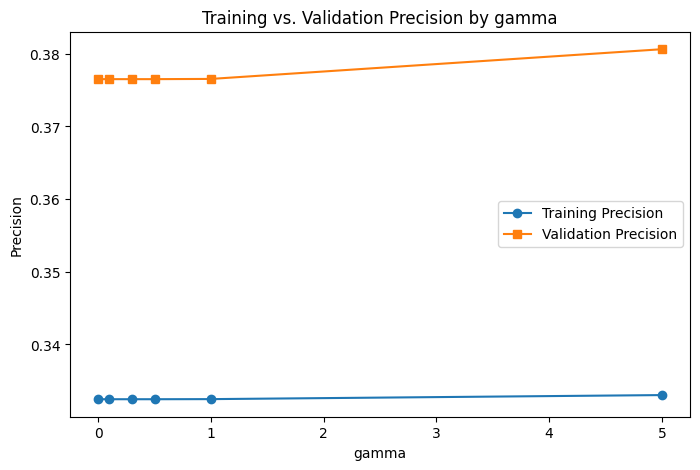

Best gamma for validation set: 5
Corresponding precision: 0.381


In [112]:
gammas = [0, 0.1, 0.3, 0.5, 1, 5]
precision_train = []
precision_val = []

for g in gammas:
    model = XGBClassifier(
        max_depth=4,
        min_child_weight=10,
        n_estimators=100, # based on the previous plot
        gamma=g,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=101,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    )
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    precision_train.append(precision_score(y_train, y_train_pred))

    y_val_pred = model.predict(X_val)
    precision_val.append(precision_score(y_val, y_val_pred))

plt.figure(figsize=(8, 5))
plt.plot(gammas, precision_train, label="Training Precision", marker='o')
plt.plot(gammas, precision_val, label="Validation Precision", marker='s')
plt.xlabel("gamma")
plt.ylabel("Precision")
plt.title("Training vs. Validation Precision by gamma")
plt.legend()
plt.show()

# Find the gamma with the highest validation precision
best_index = precision_val.index(max(precision_val))
best_gamma = gammas[best_index]
best_precision = precision_val[best_index]

print(f"Best gamma for validation set: {best_gamma}")
print(f"Corresponding precision: {best_precision:.3f}")


### Tuning subsample
To prevent overfitting and improve generalization, we tuned the subsample parameter between 0.6 and 1.0. The best performance was observed at 0.9, with a minor drop afterward.
Best subsample: 0.9
Validation precision: 0.378

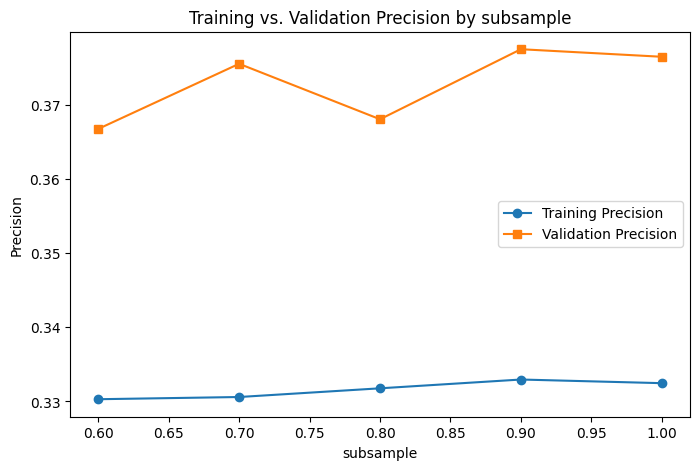

Best Subsamples for validation set: 0.9
Corresponding precision: 0.378


In [113]:
subsample_values = [0.6, 0.7, 0.8, 0.9, 1.0]
precision_train = []
precision_val = []

for subsample in subsample_values:
    xgb = XGBClassifier(
        max_depth=4,
        n_estimators=100,
        min_child_weight=10,
        gamma=0.0, # based on the previous code block
        subsample=subsample,
        random_state=101,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    )
    xgb.fit(X_train, y_train)

    # Training recall
    y_train_pred = xgb.predict(X_train)
    precision_train.append(precision_score(y_train, y_train_pred))

    # Validation recall
    y_val_pred = xgb.predict(X_val)
    precision_val.append(precision_score(y_val, y_val_pred))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(subsample_values, precision_train, label="Training Precision", marker='o')
plt.plot(subsample_values, precision_val, label="Validation Precision", marker='s')
plt.xlabel("subsample")
plt.ylabel("Precision")
plt.title("Training vs. Validation Precision by subsample")
plt.legend()
plt.show()

# Find the subsample with the highest validation precision
best_index = precision_val.index(max(precision_val))
best_subsample = subsample_values[best_index]
best_precision = precision_val[best_index]

print(f"Best Subsamples for validation set: {best_subsample}")
print(f"Corresponding precision: {best_precision:.3f}")

### Tuning colsample_bytree
To identify the optimal feature sampling rate for building trees, we tuned the colsample_bytree hyperparameter ranging from 0.5 to 1.0. A value of 0.7 yielded the best validation precision of 0.379, suggesting that limiting feature exposure per tree slightly improves generalization.

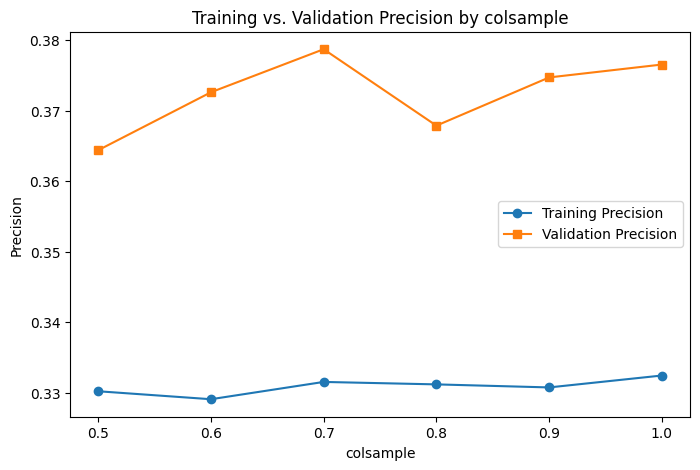

Best Colsample for validation set: 0.7
Corresponding precision: 0.379


In [114]:
colsample_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

precision_train = []
precision_val = []

for colsample in colsample_values:
    xgb = XGBClassifier(
        max_depth=4,
        n_estimators=100,
        min_child_weight=10,
        gamma=0.0,
        subsample=1.0, # based on the previous chart
        colsample_bytree=colsample,
        random_state=101,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    )
    xgb.fit(X_train, y_train)

    # Training precsion
    y_train_pred = xgb.predict(X_train)
    precision_train.append(precision_score(y_train, y_train_pred))

    # Validation precision
    y_val_pred = xgb.predict(X_val)
    precision_val.append(precision_score(y_val, y_val_pred))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(colsample_values, precision_train, label="Training Precision", marker='o')
plt.plot(colsample_values, precision_val, label="Validation Precision", marker='s')
plt.xlabel("colsample")
plt.ylabel("Precision")
plt.title("Training vs. Validation Precision by colsample")
plt.legend()
plt.show()

# Find the colsample with the highest validation precision
best_index = precision_val.index(max(precision_val))
best_colsample = colsample_values[best_index]
best_precision = precision_val[best_index]

print(f"Best Colsample for validation set: {best_colsample}")
print(f"Corresponding precision: {best_precision:.3f}")

### Tuning learning_rate
Next, we tuned the learning_rate to control model update size. We tested values from 0.1 to 0.5. A learning rate of 0.5 achieved the best validation precision of 0.382, indicating that faster learning may help in this case without excessive overfitting.

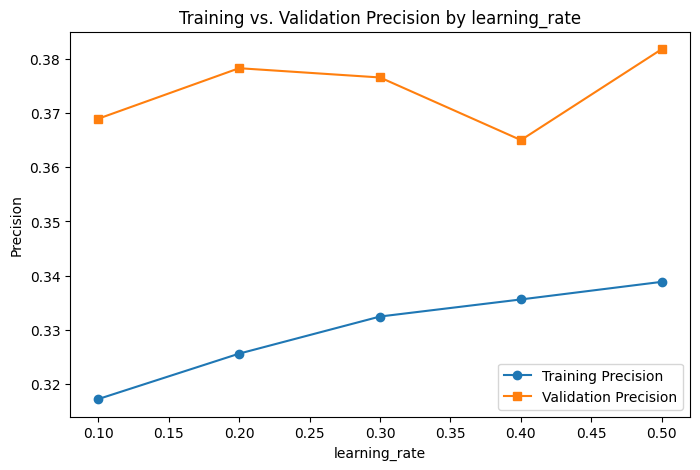

Best Learning Rate for validation set: 0.5
Corresponding precision: 0.382


In [115]:
learning_rates = [0.1, 0.2, 0.3, 0.4, 0.5]

precision_train = []
precision_val = []

for lr in learning_rates:
    xgb = XGBClassifier(
        max_depth=4,
        n_estimators=100,
        min_child_weight=10,
        gamma=0.0,
        subsample=1.0,
        colsample_bytree=1.0,
        learning_rate=lr,
        random_state=101,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    )
    xgb.fit(X_train, y_train)

    # Training precision
    y_train_pred = xgb.predict(X_train)
    precision_train.append(precision_score(y_train, y_train_pred))

    # Validation precision
    y_val_pred = xgb.predict(X_val)
    precision_val.append(precision_score(y_val, y_val_pred))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(learning_rates, precision_train, label="Training Precision", marker='o')
plt.plot(learning_rates, precision_val, label="Validation Precision", marker='s')
plt.xlabel("learning_rate")
plt.ylabel("Precision")
plt.title("Training vs. Validation Precision by learning_rate")
plt.legend()
plt.show()

# Find the learning_rate with the highest validation precision
best_index = precision_val.index(max(precision_val))
best_learning_rates = learning_rates[best_index]
best_precision = precision_val[best_index]

print(f"Best Learning Rate for validation set: {best_learning_rates}")
print(f"Corresponding precision: {best_precision:.3f}")

### Manual Grid Search Results
A manual grid search was conducted over the best-performing hyperparameter ranges:

max_depth: 4

min_child_weight: 10

n_estimators: 100

gamma: 0.0

subsample: 1.0

colsample_bytree: 0.8

learning_rate: 0.45

This configuration produced a validation precision of 0.3814 and outperformed both Decision Tree and Random Forest baselines in recall (0.7145) and F1-score (0.4973). Though slightly behind Random Forest in precision, XGBoost achieved the best overall balance.

In [116]:
from itertools import product
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define grid ranges
param_grid = {
    'max_depth': [4,5],
    'min_child_weight': [10],
    'n_estimators': [100],
    'gamma': [0.0],
    'subsample': [1.00],
    'colsample_bytree': [0.8, 1.0],
    'learning_rate': [0.30, 0.45]
}

# Create all combinations
grid = list(product(*param_grid.values()))
param_names = list(param_grid.keys())

best_precision = 0
best_metrics = {}
best_params = None

print("Running manual grid search...")

for values in grid:
    params = dict(zip(param_names, values))
    model = XGBClassifier(
        **params,
        random_state=101,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    accuracy = accuracy_score(y_val, preds)
    precision = precision_score(y_val, preds)
    recall = recall_score(y_val, preds)
    f1 = f1_score(y_val, preds)

    if precision > best_precision:
        best_precision = precision
        best_params = params
        best_metrics = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1
        }

# Print best results
print("\nBest precision on validation set:", round(best_precision, 4))
print("Best parameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

# Store in the shared model_results DataFrame
model_results.loc['2'] = {
    'Model': 'XGBoost',
    'Accuracy': best_metrics['accuracy'],
    'Precision': best_metrics['precision'],
    'Recall': best_metrics['recall'],
    'F1': best_metrics['f1'],
}

model_results.head()

Running manual grid search...

Best precision on validation set: 0.3814
Best parameters:
  max_depth: 4
  min_child_weight: 10
  n_estimators: 100
  gamma: 0.0
  subsample: 1.0
  colsample_bytree: 0.8
  learning_rate: 0.45


,Model,Accuracy,Precision,Recall,F1
0,Decision Tree,0.609900,0.373457,0.620522,0.466284
1,Random Forest,0.688805,0.444646,0.534939,0.485631
2,XGBoost,0.603306,0.381371,0.714542,0.497313


## Final Model Deployment: Random Forest Classifier

The final model selected was the **Random Forest**, as it showed the best precision on the validation set. The hyperparameters used were:

- `max_depth`: 20  
- `min_samples_leaf`: 1  
- `n_estimators`: 120  
- `class_weight`: 'balanced'  

The training and validation sets were combined and scaled using `MinMaxScaler` before retraining the model on the full set and testing it on the held-out test data.


In [130]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

# Updated best model info
best_model_name = 'Random Forest'
best_model_params = {
    'max_depth': 20,
    'min_samples_leaf': 1,
    'n_estimators': 120,
    'class_weight': 'balanced'
}

print(f"The best performing model on the validation set is: {best_model_name}")

# Combine training and validation sets
X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

# Scale the features
scaler_final = MinMaxScaler()
X_train_val_scaled = scaler_final.fit_transform(X_train_val)
X_test_scaled = scaler_final.transform(X_test)

# Train the final model
final_model = RandomForestClassifier(**best_model_params, random_state=101)
final_model.fit(X_train_val_scaled, y_train_val)

# Predict on test set
y_test_pred = final_model.predict(X_test_scaled)

# Evaluate
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_cm = confusion_matrix(y_test, y_test_pred)

# Results
print("\nTest Set Evaluation Metrics:")
print(f"Model: {best_model_name}")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1 Score: {test_f1:.4f}")
print(f"Confusion Matrix:\n{test_cm}")

The best performing model on the validation set is: Random Forest

Test Set Evaluation Metrics:
Model: Random Forest
Accuracy: 0.8019
Precision: 0.3000
Recall: 0.1035
F1 Score: 0.1539
Confusion Matrix:
[[109963   5896]
 [ 21896   2527]]


### Test Set Evaluation Results (Random Forest)

**Model Performance on Unseen Data:**

- **Accuracy:** 0.8019  
- **Precision:** 0.3000  
- **Recall:** 0.1035  
- **F1 Score:** 0.1539  

The model maintains high overall accuracy but highlights a key challenge: identifying true positive delays remains difficult due to class imbalance.


## Recommendations

- **Operational Readiness Alerts**: Deploy this model into the airline’s daily operations system to flag high-risk departures 2–3 hours in advance.
- **Schedule Buffering**: Adjust staffing and gate assignments for flights flagged as likely to be delayed.
- **Carrier Negotiation**: Use insights from delay rate by airline and aircraft model to inform contractual negotiations or scheduling priority.
- **Aircraft Planning**: Older or historically underperforming aircraft (e.g., CRJ-200) may warrant maintenance prioritization or route reassignment.

This model is not a final solution but a reliable decision support tool. Ongoing monitoring and retraining are recommended as patterns evolve.


# References

•	Bureau of Transportation Statistics. (n.d.). *T-100 domestic segment (all carriers)*. U.S. Department of Transportation. https://www.transtats.bts.gov

•	CLT Appendix. (2025). *Charlotte Douglas International Airport financial and operational data*. Hult International Business School.

•	Fernandez, J. (2025). *Predicting delays at airports*. Hult Publishing.

•	OpenAI. (2025, June 18). *Model selection, tuning, and performance analysis guidance for Random Forest, XGBoost, and Decision Tree* [ChatGPT conversation]. https://chatgpt.com/share/685309a4-6fcc-8003-84d7-ccd00f641612

•	TensorFlow. (n.d.). *Class weights and training using Keras API*. https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit

•	Scikit-learn. (n.d.). *sklearn.utils.class_weight.compute_class_weight*. https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html
